In [1]:
import os
import json
import numpy as np
import nibabel as nib
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
from pathlib import Path
import matplotlib.pyplot as plt
import random
from glob import glob
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix
np.random.seed(42)

JSON_PATH = './dataset/dataset.json'
BASE_DIR = Path('./dataset').resolve()
OUTPUT_DIR = './preprocessed'
MODALITY_INDEX = 0  # 0=FLAIR, 1=T1w, 2=T1gd, 3=T2w

In [2]:
def resize_to_256(image, mask):
    """
    Resize image and mask to 256x256 (required by SMP encoders)
    image: shape (1, H, W)
    mask: shape (H, W)
    """
    image_resized = cv2.resize(image[0], (256, 256), interpolation=cv2.INTER_LINEAR)
    mask_resized = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
    return np.expand_dims(image_resized, axis=0), mask_resized

In [3]:
def load_volume_pairs(json_path, base_dir):
    with open(json_path) as f:
        data = json.load(f)
    all_pairs = [
        {
            "image": os.path.join(base_dir, item["image"].lstrip("./")),
            "label": os.path.join(base_dir, item["label"].lstrip("./"))
        }
        for item in data["training"]
    ]
    return all_pairs

In [4]:
def preprocess_and_save(image_label_pairs, output_dir, modality_index=0):
    os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'masks'), exist_ok=True)
    index = 0

    for pair in tqdm(image_label_pairs, desc=f"Preprocessing to {output_dir}"):
        img = nib.load(pair['image']).get_fdata()[..., modality_index]
        mask = nib.load(pair['label']).get_fdata()

        for i in range(img.shape[2]):
            # only tumor slices
            if np.any(mask[:, :, i] > 0):  
                image_slice = img[:, :, i]
                mask_slice = mask[:, :, i]

                # Normalize
                image_norm = (image_slice - np.mean(image_slice)) / (np.std(image_slice) + 1e-5)
                image = np.expand_dims(image_norm, axis=0)

                # Resize
                image_resized, mask_resized = resize_to_256(image, mask_slice)

                # Save
                np.save(os.path.join(output_dir, 'images', f'{index:06d}.npy'), image_resized)
                np.save(os.path.join(output_dir, 'masks', f'{index:06d}.npy'), mask_resized)
                index += 1

    print(f"✅ Saved {index} 2D slices to {output_dir}")

In [5]:
class BRATSPreprocessedDataset(Dataset):
    def __init__(self, data_dir):
        self.image_dir = os.path.join(data_dir, 'images')
        self.mask_dir = os.path.join(data_dir, 'masks')
        self.filenames = sorted(os.listdir(self.image_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        image = np.load(os.path.join(self.image_dir, self.filenames[idx]))
        mask = np.load(os.path.join(self.mask_dir, self.filenames[idx]))
        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

In [6]:
# 1. Load full list of volumes
all_volumes = load_volume_pairs(JSON_PATH, BASE_DIR)

# 2. Split by volume
train_vols, valtest_vols = train_test_split(all_volumes, test_size=0.3, random_state=42)
val_vols, test_vols = train_test_split(valtest_vols, test_size=0.5, random_state=42)

# 3. Preprocess and save slices from each split
preprocess_and_save(train_vols, os.path.join(OUTPUT_DIR, 'train'), modality_index=MODALITY_INDEX)
preprocess_and_save(val_vols, os.path.join(OUTPUT_DIR, 'val'), modality_index=MODALITY_INDEX)
preprocess_and_save(test_vols, os.path.join(OUTPUT_DIR, 'test'), modality_index=MODALITY_INDEX)

Preprocessing to ./preprocessed\train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 338/338 [02:32<00:00,  2.22it/s]


✅ Saved 23659 2D slices to ./preprocessed\train


Preprocessing to ./preprocessed\val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:24<00:00,  2.94it/s]


✅ Saved 5068 2D slices to ./preprocessed\val


Preprocessing to ./preprocessed\test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:24<00:00,  2.94it/s]

✅ Saved 5028 2D slices to ./preprocessed\test


In [6]:
# 4. Load ready-to-train datasets
train_dataset = BRATSPreprocessedDataset(os.path.join(OUTPUT_DIR, 'train'))
val_dataset = BRATSPreprocessedDataset(os.path.join(OUTPUT_DIR, 'val'))
test_dataset = BRATSPreprocessedDataset(os.path.join(OUTPUT_DIR, 'test'))

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

BATCH_SIZE = 16
NUM_WORKERS = 0 # for windows 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

23659
5068
5028


In [7]:
def visualize_predictions_from_dataset(dataset, num_samples=2, title=''):
    indices = random.sample(range(len(dataset)), num_samples)
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        image = image.squeeze().numpy()
        mask = mask.numpy()

        plt.figure(figsize=(8, 3))
        plt.suptitle(f"{title} Sample {i + 1}", fontsize=14)

        plt.subplot(1, 2, 1)
        plt.imshow(image, cmap='gray')
        plt.title('Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='nipy_spectral')
        plt.title('Mask')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

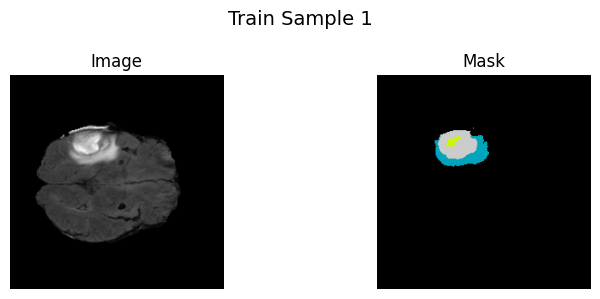

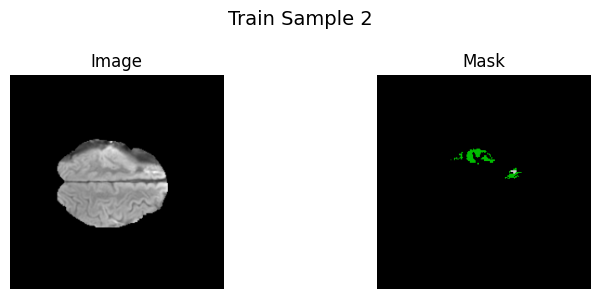

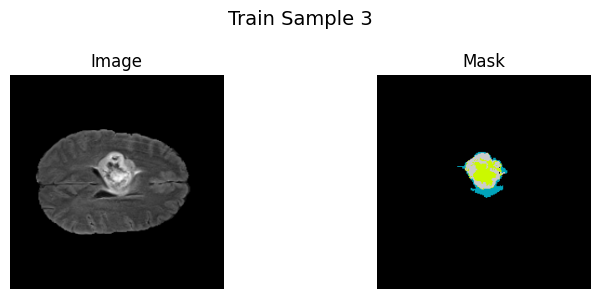

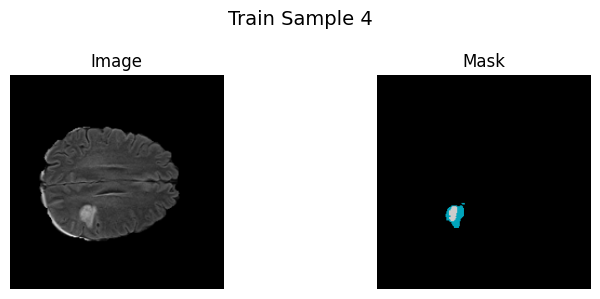

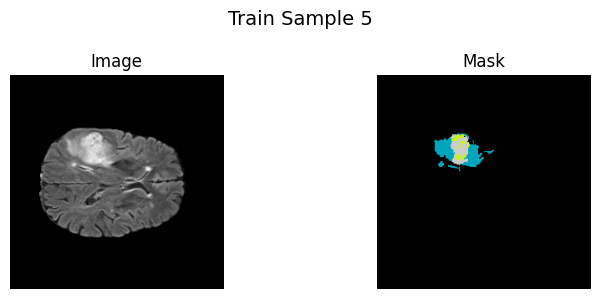

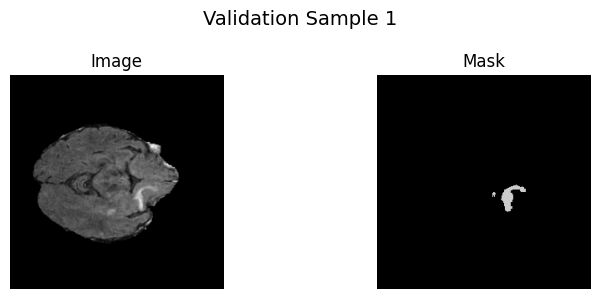

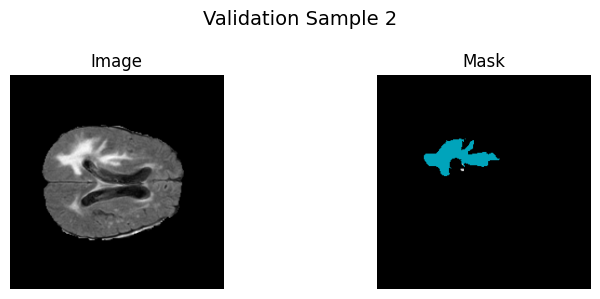

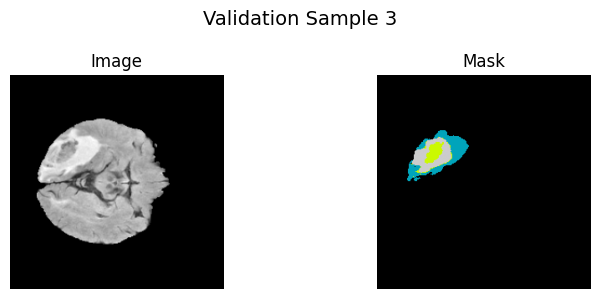

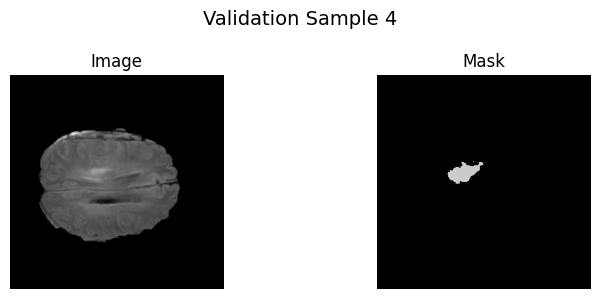

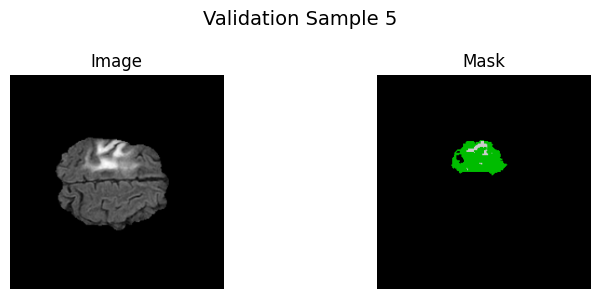

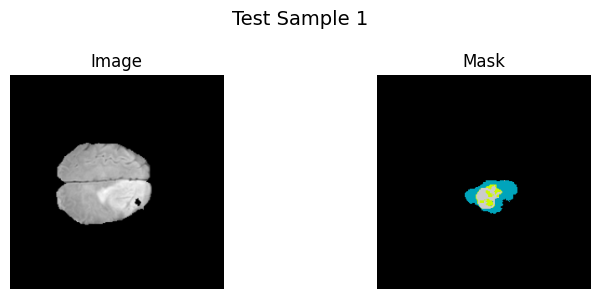

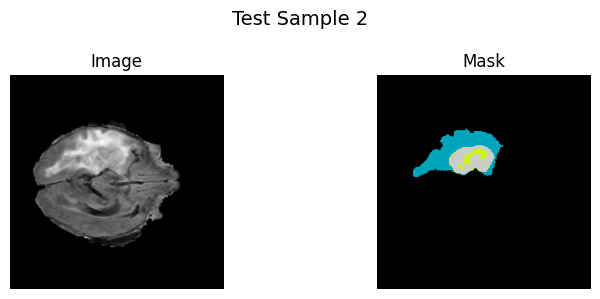

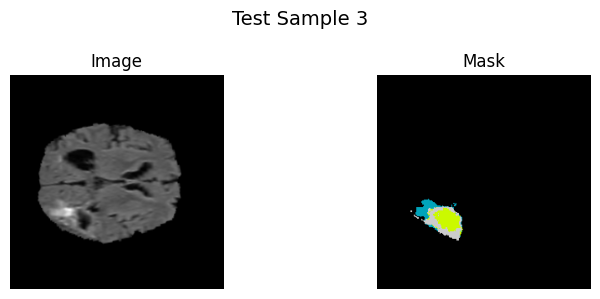

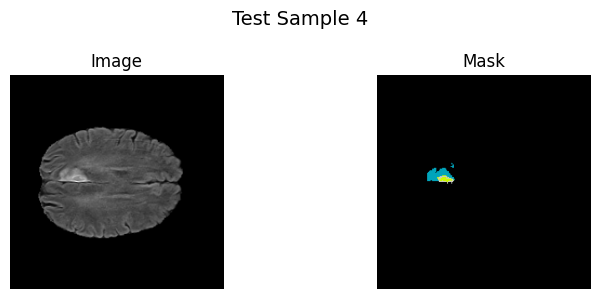

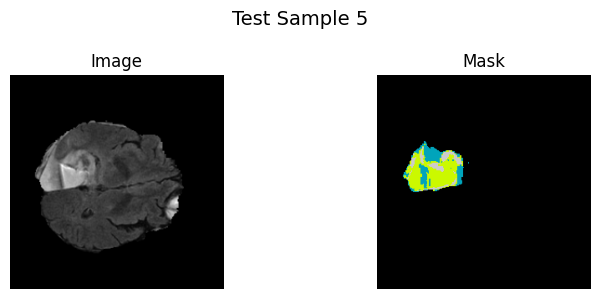

In [8]:
visualize_predictions_from_dataset(train_dataset, num_samples=5, title='Train')
visualize_predictions_from_dataset(val_dataset, num_samples=5, title='Validation')
visualize_predictions_from_dataset(test_dataset, num_samples=5, title='Test')

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=4, features=[64, 128, 256, 512]):
        super(UNet2D, self).__init__()

        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()

        # Encoder (Down)
        for feature in features:
            self.encoder.append(self._conv_block(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = self._conv_block(features[-1], features[-1]*2)

        # Decoder (Up)
        for feature in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.decoder.append(self._conv_block(feature*2, feature))

        # Final output layer
        self.output_layer = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def _conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        skip_connections = []
        for down in self.encoder:
            x = down(x)
            skip_connections.append(x)
            x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.decoder), 2):
            x = self.decoder[idx](x)
            skip_connection = skip_connections[idx // 2]

            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])

            x = torch.cat((skip_connection, x), dim=1)
            x = self.decoder[idx + 1](x)

        return self.output_layer(x)


In [10]:
def get_pretrained_unet(encoder='resnet34', encoder_weights='imagenet', in_channels=1, classes=4):
    model = smp.Unet(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=in_channels, # 1 for grayscale
        classes=classes,
        activation=None
    )
    return model

In [11]:
def dice_score(preds, targets, num_classes=4):
    preds = torch.argmax(preds, dim=1)
    dice = []

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice_cls = (2. * intersection + 1e-5) / (union + 1e-5)
        dice.append(dice_cls.item())
    
    return sum(dice) / len(dice)

In [12]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
        elif val_loss > self.best_score - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_loss
            self.counter = 0


In [29]:
def train_model(model, train_dataset, val_dataset=None, num_epochs=10, batch_size=8, lr=1e-3,
                device='cuda' if torch.cuda.is_available() else 'cpu', save_path='model_best.pth'):
    from torch.utils.data import DataLoader
    import torch.nn as nn
    import torch.optim as optim
    import matplotlib.pyplot as plt
    from tqdm import tqdm

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False) if val_dataset else None

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    stopper = EarlyStopping(patience=5)

    train_losses, val_losses = [], []
    train_dices, val_dices = [], []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_dice = 0.0, 0.0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_dice += dice_score(preds, masks)
            loop.set_postfix(loss=loss.item())

        avg_loss = train_loss / len(train_loader)
        avg_dice = train_dice / len(train_loader)
        train_losses.append(avg_loss)
        train_dices.append(avg_dice)

        print(f"Train Loss: {avg_loss:.4f}, Dice: {avg_dice:.4f}")

        if val_loader:
            model.eval()
            val_loss, val_dice = 0.0, 0.0
            with torch.no_grad():
                for images, masks in val_loader:
                    images, masks = images.to(device), masks.to(device)
                    preds = model(images)
                    loss = criterion(preds, masks)
                    val_loss += loss.item()
                    val_dice += dice_score(preds, masks)

            avg_val_loss = val_loss / len(val_loader)
            avg_val_dice = val_dice / len(val_loader)
            val_losses.append(avg_val_loss)
            val_dices.append(avg_val_dice)

            print(f"Val Loss: {avg_val_loss:.4f}, Dice: {avg_val_dice:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                torch.save(model.state_dict(), save_path)
                print(f"Best model saved at epoch {epoch+1}.")

            stopper(avg_val_loss)
            if stopper.early_stop:
                print("Early stopping triggered.")
                break

    # Plotting
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    if val_losses: plt.plot(val_losses, label='Val Loss')
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curve")
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_dices, label='Train Dice')
    if val_dices: plt.plot(val_dices, label='Val Dice')
    plt.xlabel("Epoch"); plt.ylabel("Dice Score"); plt.title("Dice Score Curve")
    plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model


In [30]:
model_2D_UNET = get_pretrained_unet(encoder='resnet34', encoder_weights='imagenet')
model_2D_UNET_pretrained = get_pretrained_unet(encoder='resnet34', encoder_weights='imagenet')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_2D_UNET.to(device)
model_2D_UNET_pretrained.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [31]:
def evaluate_metrics(model, dataset, num_classes=4, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    
    dice_scores = np.zeros(num_classes)
    total_pixels = 0
    correct_pixels = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Pixel accuracy
            correct_pixels += (preds == masks).sum().item()
            total_pixels += torch.numel(masks)

            # Dice score
            for cls in range(num_classes):
                pred_cls = (preds == cls).float()
                true_cls = (masks == cls).float()
                intersection = (pred_cls * true_cls).sum()
                union = pred_cls.sum() + true_cls.sum()
                dice = (2 * intersection + 1e-5) / (union + 1e-5)
                dice_scores[cls] += dice.item()

            # Confusion matrix
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(masks.cpu().numpy().flatten())

    avg_dice = dice_scores / len(loader)
    accuracy = correct_pixels / total_pixels
    cm = confusion_matrix(all_targets, all_preds, labels=range(num_classes))

    print(f"\n Evaluation Results:")
    for i, d in enumerate(avg_dice):
        print(f"  Dice Class {i}: {d:.4f}")
    print(f"  Pixel Accuracy: {accuracy:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    return avg_dice, accuracy, cm


In [32]:
def visualize_predictions(model, val_dataset, num_samples=5, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    indices = random.sample(range(len(val_dataset)), num_samples)

    with torch.no_grad():
        for idx in indices:
            image, true_mask = val_dataset[idx]
            image = image.unsqueeze(0).to(device)
            pred_mask = model(image)
            pred_mask = torch.argmax(pred_mask, dim=1).squeeze(0).cpu().numpy()
            true_mask = true_mask.numpy()
            image = image.squeeze().cpu().numpy()

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(image, cmap='gray')
            plt.title('Image')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(true_mask, cmap='nipy_spectral')
            plt.title('Ground Truth')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask, cmap='nipy_spectral')
            plt.title('Prediction')
            plt.axis('off')
            plt.show()

In [ ]:
train_model(model_2D_UNET, train_dataset, val_dataset, num_epochs=10)

Epoch 1/10:  19%|█████████████████████▊                                                                                            | 566/2958 [00:29<02:01, 19.71it/s, loss=0.0364]

In [ ]:
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"Model saved to: {path}")

In [ ]:
model_path = 'models/2D_UNET.pth'
os.makedirs('./models', exist_ok=True)
save_model(model_2D_UNET, model_path)

In [ ]:
evaluate_metrics(model_2D_UNET, test_dataset)
visualize_predictions(model_2D_UNET, test_dataset, num_samples=8)

In [ ]:
train_model(model_2D_UNET_pretrained, train_dataset, val_dataset, num_epochs=10)

In [ ]:
model_path = 'models/2D_UNET_pretrained.pth'
save_model(model_2D_UNET_pretrained, model_path)

In [ ]:
evaluate_metrics(model_2D_UNET_pretrained, test_dataset)
visualize_predictions(model_2D_UNET_pretrained, test_dataset, num_samples=10)